In [2]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 9.9 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.3 MB 17.9 MB/s eta 0:00:01
   ----------------------------- ---------- 8.4/11.3 MB 17.7 MB/s eta 0:00:01
   ------------------------------------- -- 10.5/11.3 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 14.5 MB/s  0:00:00

   ---------------------------------------- 0/5 [wrapt]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------------ --------------- 3/5 [formulaic]
   ------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\georg\AppData\Local\Temp\ipykernel_26516\2616108250.py:46: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(clean_series)
C:\Users\georg\AppData\Local\Temp\ipykernel_26516\2616108250.py:46: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(clean_series)



--- Prueba ADF: Serie Original ---
Estadístico ADF : 8.0018
p-valor         : 1.00000e+00
Resultado       : No estacionaria
Valores Críticos: {'1%': np.float64(-3.439006442437876), '5%': np.float64(-2.865360521688131), '10%': np.float64(-2.5688044403756587)}

--- Prueba ADF: Primera Diferencia (d=1) ---
Estadístico ADF : -5.0204
p-valor         : 2.02187e-05
Resultado       : Estacionaria (p < 0.05)
Valores Críticos: {'1%': np.float64(-3.4390179167598367), '5%': np.float64(-2.8653655786032237), '10%': np.float64(-2.5688071343462777)}


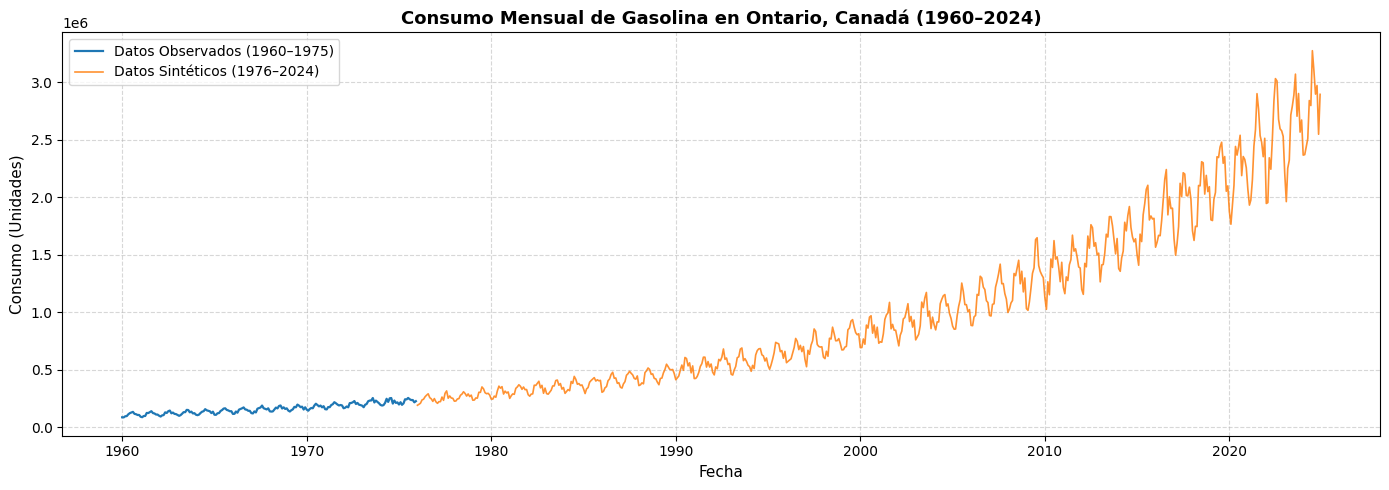

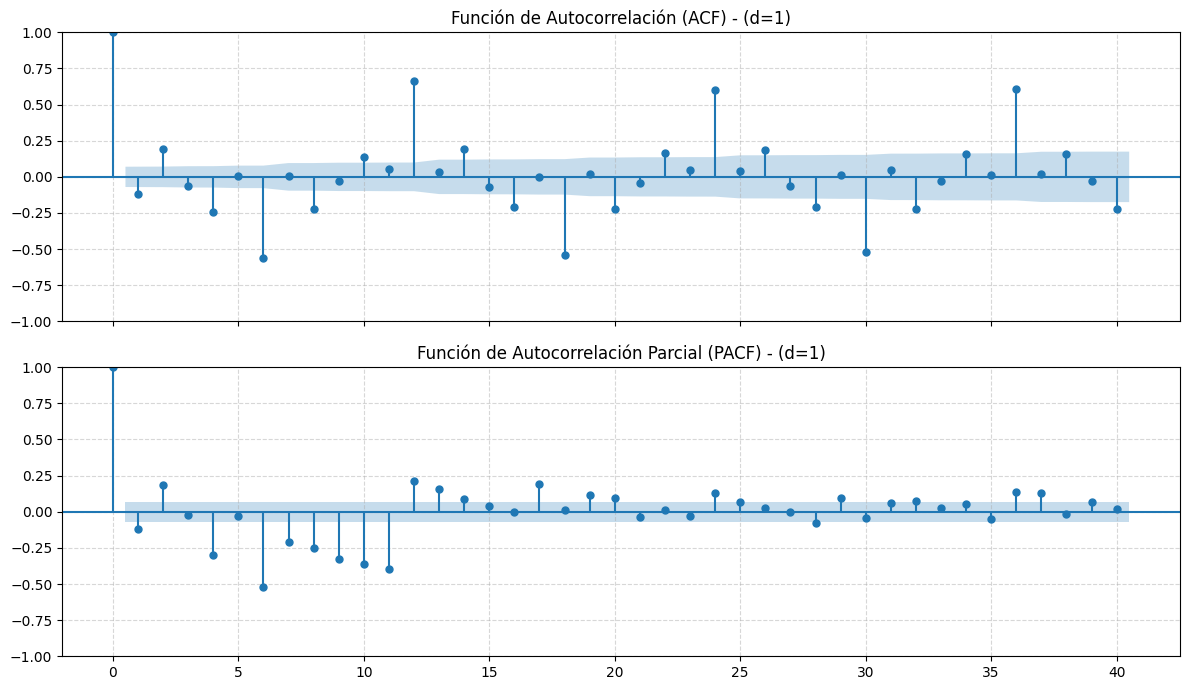


Ajustando modelo ARIMA(2, 1, 2)...


c:\Users\georg\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
c:\Users\georg\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


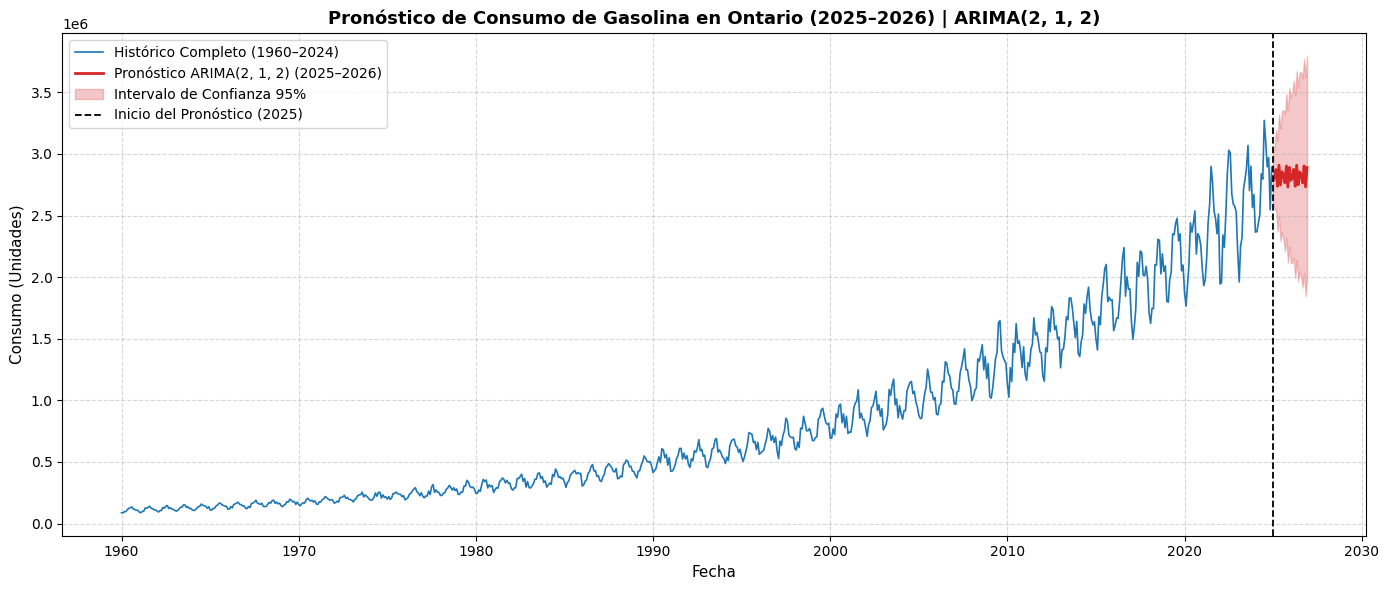


Primeras predicciones:
              prediccion   ic_inferior   ic_superior
2025-01-01  2.784491e+06  2.598108e+06  2.970875e+06
2025-02-01  2.810734e+06  2.549669e+06  3.071800e+06
2025-03-01  2.874286e+06  2.552215e+06  3.196357e+06
2025-04-01  2.738187e+06  2.368179e+06  3.108194e+06
2025-05-01  2.910044e+06  2.495229e+06  3.324859e+06


In [4]:
"""
Módulo de Pronóstico y Análisis de Series Temporales (ARIMA).
Caso de estudio: Consumo mensual de gasolina en Ontario (1960 - 2026).
"""

from typing import Tuple
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from statsmodels.tsa.stattools import adfuller


class GasConsumptionForecaster:
    """Pipeline de preprocesamiento, análisis econométrico y proyección."""

    def __init__(self, filepath: str, date_col: str = "fecha"):
        self.filepath = filepath
        self.date_col = date_col
        self.df: pd.DataFrame = pd.DataFrame()
        self.target_col: str = ""
        self.model_fit: ARIMAResults = None

    def load_and_preprocess(self) -> pd.DataFrame:
        """Carga, valida y ordena cronológicamente la serie."""
        self.df = pd.read_csv(self.filepath)

        self.target_col = (
            "consumo_combustible"
            if "consumo_combustible" in self.df.columns
            else "consumo"
        )

        self.df[self.date_col] = pd.to_datetime(self.df[self.date_col])
        self.df = self.df.sort_values(self.date_col).reset_index(drop=True)
        self.df.set_index(self.date_col, inplace=True)
        return self.df

    @staticmethod
    def check_stationarity(
        series: pd.Series, label: str = "Serie"
    ) -> Tuple[float, float, bool]:
        """Aplica la prueba Augmented Dickey-Fuller (ADF) para evaluar estacionariedad."""
        clean_series = series.dropna()
        result = adfuller(clean_series)
        stat, p_val, crit_vals = result[0], result[1], result[4]
        is_stationary = p_val < 0.05

        print(f"\n--- Prueba ADF: {label} ---")
        print(f"Estadístico ADF : {stat:.4f}")
        print(f"p-valor         : {p_val:.5e}")
        print(f"Resultado       : {'Estacionaria (p < 0.05)' if is_stationary else 'No estacionaria'}")
        print(f"Valores Críticos: {crit_vals}")
        return stat, p_val, is_stationary

    def plot_historical(self) -> None:
        """Grafica la serie histórica diferenciando fuentes observadas vs. sintéticas."""
        plt.figure(figsize=(14, 5))

        if "origen_dato" in self.df.columns:
            obs = self.df[self.df["origen_dato"] == "observado"]
            sint = self.df[self.df["origen_dato"] == "sintetico"]
            plt.plot(obs.index, obs[self.target_col], label="Datos Observados (1960–1975)", color="#1f77b4", lw=1.6)
            plt.plot(sint.index, sint[self.target_col], label="Datos Sintéticos (1976–2024)", color="#ff7f0e", lw=1.2, alpha=0.85)
        else:
            plt.plot(self.df.index, self.df[self.target_col], label="Consumo Histórico", color="#1f77b4", lw=1.5)

        plt.title("Consumo Mensual de Gasolina en Ontario, Canadá (1960–2024)", fontsize=13, fontweight="bold")
        plt.xlabel("Fecha", fontsize=11)
        plt.ylabel("Consumo (Unidades)", fontsize=11)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

    def plot_acf_pacf(self, lags: int = 40) -> None:
        """Genera los correlogramas ACF y PACF para la serie con primera diferenciación."""
        diff_series = self.df[self.target_col].diff().dropna()

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
        plot_acf(diff_series, lags=lags, ax=ax1, title="Función de Autocorrelación (ACF) - (d=1)")
        plot_pacf(diff_series, lags=lags, ax=ax2, method="ywm", title="Función de Autocorrelación Parcial (PACF) - (d=1)")
        ax1.grid(True, linestyle="--", alpha=0.5)
        ax2.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    def train_and_forecast(
        self, order: Tuple[int, int, int] = (2, 1, 2), forecast_steps: int = 24
    ) -> pd.DataFrame:
        """Ajusta el modelo ARIMA y genera el pronóstico con intervalos de confianza del 95%."""
        series = self.df[self.target_col].asfreq("MS")

        print(f"\nAjustando modelo ARIMA{order}...")
        self.model_fit = ARIMA(series, order=order).fit()

        forecast_res = self.model_fit.get_forecast(steps=forecast_steps)
        fc_mean = forecast_res.predicted_mean
        fc_ci = forecast_res.conf_int(alpha=0.05)

        # Gráfica de proyección
        plt.figure(figsize=(14, 6))
        plt.plot(self.df.index, self.df[self.target_col], label="Histórico Completo (1960–2024)", color="#1f77b4", lw=1.2)
        plt.plot(fc_mean.index, fc_mean.values, label=f"Pronóstico ARIMA{order} (2025–2026)", color="#d62728", lw=2)
        plt.fill_between(
            fc_mean.index,
            fc_ci.iloc[:, 0],
            fc_ci.iloc[:, 1],
            color="#d62728",
            alpha=0.25,
            label="Intervalo de Confianza 95%"
        )
        plt.axvline(x=fc_mean.index[0], color="black", linestyle="--", lw=1.3, label="Inicio del Pronóstico (2025)")
        plt.title(f"Pronóstico de Consumo de Gasolina en Ontario (2025–2026) | ARIMA{order}", fontsize=13, fontweight="bold")
        plt.xlabel("Fecha", fontsize=11)
        plt.ylabel("Consumo (Unidades)", fontsize=11)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.legend(loc="upper left")
        plt.tight_layout()
        plt.show()

        df_forecast = pd.DataFrame({
            "prediccion": fc_mean,
            "ic_inferior": fc_ci.iloc[:, 0],
            "ic_superior": fc_ci.iloc[:, 1]
        })
        return df_forecast


if __name__ == "__main__":
    # Ruta del archivo CSV
    DATA_PATH = r"C:\Users\georg\Downloads\consumo_gasolina_ontario_1960_2024.csv"
    
    forecaster = GasConsumptionForecaster(filepath=DATA_PATH)
    data = forecaster.load_and_preprocess()

    # 1. Pruebas de raíz unitaria
    forecaster.check_stationarity(data[forecaster.target_col], label="Serie Original")
    forecaster.check_stationarity(data[forecaster.target_col].diff(), label="Primera Diferencia (d=1)")

    # 2. Análisis visual y correlogramas
    forecaster.plot_historical()
    forecaster.plot_acf_pacf(lags=40)

    # 3. Modelado y horizonte predictivo a 24 pasos (2025 - 2026)
    forecast_results = forecaster.train_and_forecast(order=(2, 1, 2), forecast_steps=24)
    print("\nPrimeras predicciones:")
    print(forecast_results.head())